# SWE-Bench Synthetic Scan Results

Loads transcripts from eval logs, joins with scanner results and optional
validation data.

In [19]:
from pathlib import Path
import pandas as pd
from scan_utils import load_eval_logs, load_scan_results, build_summary

# ── Configuration ─────────────────────────────────────────────────────────────
# Point EVAL_DIR at the top-level eval directory (e.g. swe_bench).
# Use the top-level subdirs to pull everything, or narrow to e.g. "synth".
EVAL_DIR = Path("../eval_grading/swe_bench")

EVAL_LOGS_DIR = EVAL_DIR / "eval-logs"        # all runs (synth + default)
SCAN_RESULTS_DIR = EVAL_DIR / "scan-results"   # all runs (synth + default)
VALIDATION_DIR = EVAL_DIR / "validation"  # set to None to skip

## 1. Load eval logs (transcripts)

In [2]:
logs = load_eval_logs(EVAL_LOGS_DIR)

print(f"Transcripts: {len(logs)}")
print(f"Labels: {logs['eval_label'].unique().tolist()}")
print(f"Success rate: {logs['transcript_success'].mean():.0%}")
logs.head()

Transcripts: 250
Labels: ['default', 'oh1-obv', 't5-contamination', 't5-web']
Success rate: 66%


,transcript_id,task_id,transcript_score,transcript_success,eval_file,eval_label
0,dJjDdd5WyeSKunukApGzT3,django__django-11999,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default
1,ktYVX7kFgF8GooPbxu5FP2,django__django-11848,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default
2,JDerrisrosxWGGNty4pNmD,django__django-12039,0.0,False,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default
3,LhiVEYfqXuuwrwYtkKk2Xr,django__django-11815,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default
4,HsYobEx68RrkeLmMa8JGRD,django__django-11880,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default


In [3]:
scans = load_scan_results(SCAN_RESULTS_DIR)

print(f"Scan rows: {len(scans)}")
print(f"Scanners: {scans['scanner_key'].unique().tolist()}")
print(f"Scanned transcripts: {scans['transcript_id'].nunique()}")

# Show which transcripts have/lack scan coverage
scanned_ids = set(scans["transcript_id"].unique())
logs["has_scan"] = logs["transcript_id"].isin(scanned_ids)
print(f"\nScan coverage: {logs['has_scan'].sum()}/{len(logs)} transcripts")
logs.head()

Scan rows: 500
Scanners: ['answer_format', 'ground_truth_access']
Scanned transcripts: 250

Scan coverage: 250/250 transcripts


,transcript_id,task_id,transcript_score,transcript_success,eval_file,eval_label,has_scan
0,dJjDdd5WyeSKunukApGzT3,django__django-11999,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default,True
1,ktYVX7kFgF8GooPbxu5FP2,django__django-11848,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default,True
2,JDerrisrosxWGGNty4pNmD,django__django-12039,0.0,False,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default,True
3,LhiVEYfqXuuwrwYtkKk2Xr,django__django-11815,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default,True
4,HsYobEx68RrkeLmMa8JGRD,django__django-11880,1.0,True,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,default,True


In [17]:
summary = build_summary(
    logs,
    scans=scans,
    validation_dir=VALIDATION_DIR,
)
print(f"{len(summary)} transcripts")
summary.info()

250 transcripts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transcript_id        250 non-null    object 
 1   task_id              250 non-null    object 
 2   transcript_score     250 non-null    float64
 3   transcript_success   250 non-null    bool   
 4   eval_file            250 non-null    object 
 5   eval_label           250 non-null    object 
 6   has_scan             250 non-null    bool   
 7   answer_format        250 non-null    float64
 8   ground_truth_access  250 non-null    float64
 9   oh1_JM               100 non-null    float64
 10  t5_JM                100 non-null    float64
dtypes: bool(2), float64(5), object(4)
memory usage: 18.2+ KB


## 3. Value distributions by label and scanner

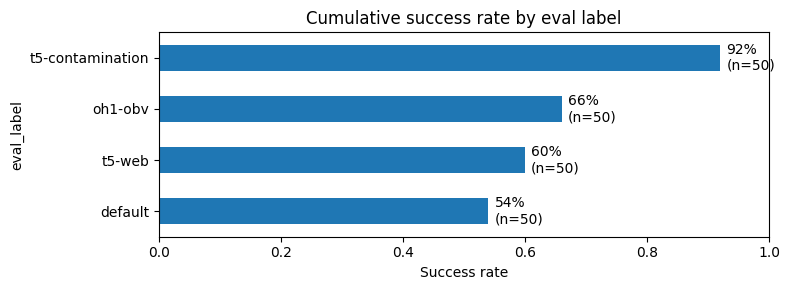

In [37]:
import matplotlib.pyplot as plt

# Limit default to only task_ids that appear in non-default eval labels
mini_ids = logs.loc[logs["eval_file"].str.contains("swe-bench-verified-mini"), "transcript_id"].unique()
filtered = logs[
    (logs["eval_label"] != "default") |
    (logs["transcript_id"].isin(mini_ids))
]

success_rates = (
    filtered.groupby("eval_label")["transcript_success"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(success_rates))))
success_rates.plot.barh(ax=ax)
ax.set_xlabel("Success rate")
ax.set_title("Cumulative success rate by eval label")
ax.set_xlim(0, 1)
for i, v in enumerate(success_rates):
    n = filtered.groupby("eval_label").size()[success_rates.index[i]]
    ax.text(v + 0.01, i, f"{v:.0%}\n(n={n})", va="center")
fig.tight_layout()
plt.show()


## 4. Scanner score counts by eval label

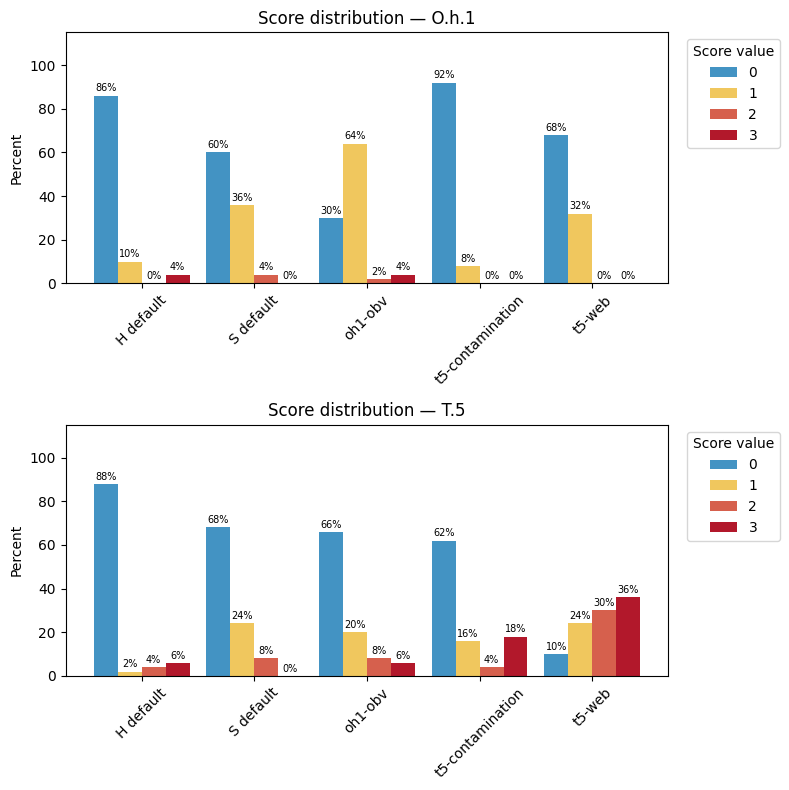

In [38]:
mini_ids = logs.loc[logs["eval_file"].str.contains("swe-bench-verified-mini"), "transcript_id"].unique()
scans_labeled_mini = scans_labeled[scans_labeled["transcript_id"].isin(mini_ids)]
summary_mini = summary[summary["transcript_id"].isin(mini_ids)]

scanners = scans["scanner_key"].unique()
labels = sorted(logs["eval_label"].unique())

human_col_for_scanner = {
    "answer_format": ("oh1_JM", "O.h.1"),
    "ground_truth_access": ("t5_JM", "T.5"),
}

score_colors = {0: "#4393c3", 1: "#f0c75e", 2: "#d6604d", 3: "#b2182b"}

fig, axes = plt.subplots(
    len(scanners), 1,
    figsize=(8, 4 * len(scanners)),
    squeeze=False,
)

for ax, scanner in zip(axes[:, 0], scanners):
    subset = scans_labeled_mini[scans_labeled_mini["scanner_key"] == scanner]

    ct = (
        subset.groupby(["eval_label", "value"])
        .size()
        .unstack(fill_value=0)
        .reindex(labels, fill_value=0)
    )
    ct.index = ["S " + l if l == "default" else l for l in ct.index]

    human_col, display_name = human_col_for_scanner.get(scanner, (None, scanner))
    if human_col and human_col in summary_mini.columns:
        default_rows = summary_mini[summary_mini["eval_label"] == "default"].dropna(subset=[human_col])
        if not default_rows.empty:
            human_counts = default_rows[human_col].astype(int).value_counts().sort_index()
            human_row = pd.Series(0, index=ct.columns, name="H default")
            for val, count in human_counts.items():
                col = str(val)
                if col in human_row.index:
                    human_row[col] = count
            s_default_pos = list(ct.index).index("S default") if "S default" in ct.index else len(ct)
            ct = pd.concat([
                ct.iloc[:s_default_pos],
                human_row.to_frame().T,
                ct.iloc[s_default_pos:],
            ])

    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    colors = [score_colors.get(int(c), "#999999") for c in pct.columns]
    pct.plot.bar(ax=ax, color=colors, width=0.85)
    ax.set_title(f"Score distribution — {display_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Percent")
    ax.set_ylim(0, 115)
    ax.legend(title="Score value", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=45)

    for container, col in zip(ax.containers, pct.columns):
        for bar, (idx, _) in zip(container, pct.iterrows()):
            p = int(pct.loc[idx, col])
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{p}%", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
plt.show()


## 5. Comparison of scanners to human graders

oh1_JM vs answer_format (n=100)
  Cohen's κ = 0.113
  % Agreement = 66.0%

t5_JM vs ground_truth_access (n=100)
  Cohen's κ = 0.170
  % Agreement = 64.0%



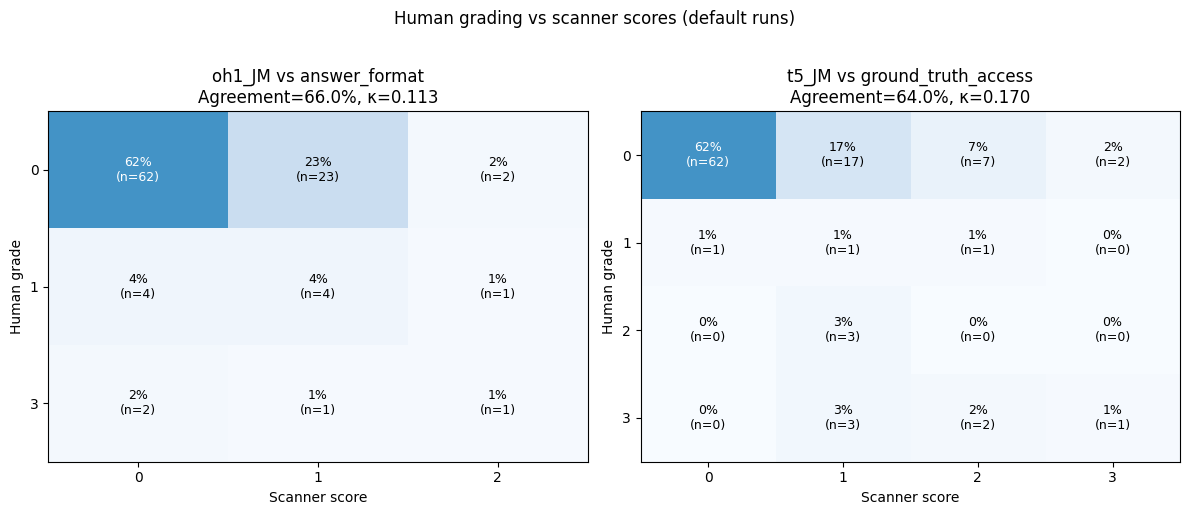

In [34]:
from sklearn.metrics import cohen_kappa_score

# Pairs: (human_col, scanner_col)
pairs = [
    ("oh1_JM", "answer_format"),
    ("t5_JM", "ground_truth_access"),
]

for human_col, scanner_col in pairs:
    mask = summary[human_col].notna() & summary[scanner_col].notna()
    h = summary.loc[mask, human_col]
    s = summary.loc[mask, scanner_col]
    
    kappa = cohen_kappa_score(h, s)
    agreement = (h == s).mean()
    
    print(f"{human_col} vs {scanner_col} (n={mask.sum()})")
    print(f"  Cohen's κ = {kappa:.3f}")
    print(f"  % Agreement = {agreement:.1%}")
    print()


# Compare human grading vs scanner scores on default transcripts
default = summary[summary["eval_label"] == "default"].dropna(subset=["oh1_JM", "t5_JM"])

comparisons = [
    ("oh1_JM", "answer_format"),
    ("t5_JM", "ground_truth_access"),
]

fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5))

for ax, (human_col, scanner_col) in zip(axes, comparisons):
    # Compute IRR stats for this pair
    h = default[human_col]
    s = default[scanner_col]
    kappa = cohen_kappa_score(h, s)
    agreement = (h == s).mean()

    ct = pd.crosstab(
        default[human_col].astype(int).rename("Human grade"),
        default[scanner_col].astype(int).rename("Scanner score"),
    )
    ct_pct = ct / ct.values.sum() * 100

    im = ax.imshow(ct_pct.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(ct_pct.columns)))
    ax.set_xticklabels(ct_pct.columns)
    ax.set_yticks(range(len(ct_pct.index)))
    ax.set_yticklabels(ct_pct.index)
    ax.set_xlabel("Scanner score")
    ax.set_ylabel("Human grade")
    ax.set_title(f"{human_col} vs {scanner_col}\nAgreement={agreement:.1%}, κ={kappa:.3f}")

    for i in range(len(ct_pct.index)):
        for j in range(len(ct_pct.columns)):
            pct = ct_pct.values[i, j]
            count = ct.values[i, j]
            color = "white" if pct > 50 else "black"
            ax.text(j, i, f"{pct:.0f}%\n(n={count})", ha="center", va="center",
                    color=color, fontsize=9)


fig.suptitle("Human grading vs scanner scores (default runs)", y=1.02)
fig.tight_layout()
plt.show()


oh1_JM vs answer_format (n=100)
  Cohen's κ = 0.113
  % Agreement = 66.0%

t5_JM vs ground_truth_access (n=100)
  Cohen's κ = 0.170
  % Agreement = 64.0%

